## Chain Using LangGraph

In this section we will see how we can build a simple chain using LangGraph that uses 4 important concepts.

- How to use chat messages as out graph state
- How to use chat models in graph nodes
- How to bind tools to out LLM in chat models
- How to execute the tools call in our graph nodes

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY") # type: ignore
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY") # type: ignore

### How to use chat messages as our graph state

### Messages

We can use messages which can be used to caputre different roles within a conversation. LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage. These represent a message from the user, from chat model, for the chat model to instruct behabior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata(e.g., often populated by model provider fo AIMessages)

In [5]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Please tell me how can i help", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name = "Luis"))
messages.append(AIMessage(content=f"Which programming language want to learn?", name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language", name = "Luis"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can i help
================================ Human Message =================================
Name: Luis

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language want to learn?
================================ Human Message =================================
Name: Luis

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI

In [7]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="qwen/qwen3-32b")
result = llm_groq.invoke(messages)
result

AIMessage(content='<think>\nOkay, the user wants to learn Python. Let me start by breaking down how to approach this. First, I need to figure out their current level. Since they haven\'t mentioned any experience, I should assume they\'re a beginner.\n\nI should outline a learning path. Start with the basics: variables, data types, control structures. Then move on to functions, data structures like lists and dictionaries. Maybe next step is working with files and error handling. After that, more advanced topics like OOP and libraries. Then introduce projects to apply what they\'ve learned.\n\nWait, the user might need resources. I should mention free platforms like Codecademy, freeCodeCamp, and Coursera. Also, books like "Automate the Boring Stuff" are great for beginners. Oh, and interactive tutorials on Replit or Jupyter Notebooks could be helpful.\n\nProjects are important for practice. Suggesting simple projects like a calculator, to-do list, or web scraper. Maybe mention contributi

In [8]:
result.response_metadata

{'token_usage': {'completion_tokens': 1528,
  'prompt_tokens': 54,
  'total_tokens': 1582,
  'completion_time': 3.1174018119999998,
  'completion_tokens_details': None,
  'prompt_time': 0.00192336,
  'prompt_tokens_details': None,
  'queue_time': 0.17368089,
  'total_time': 3.119325172},
 'model_name': 'qwen/qwen3-32b',
 'system_fingerprint': 'fp_2bfcc54d36',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools

Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema.

In [27]:
def add(a:int, b:int) -> int:
    """ Add a and b
    Args:
        a (int): firts int
        b (int): second int

    Returns:
        int
    """
    return a + b

### Binding tool with LLM

In [45]:
llm_with_tools = llm_groq.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2?", name="Luis")])
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2 plus 2?" I need to figure out how to respond. Let me check the tools provided. There\'s a function called add that takes two integers, a and b. The description says it adds them. So, for 2 plus 2, I should call the add function with a=2 and b=2. That should give the correct result. I\'ll make sure the parameters are integers as specified. No other tools are available, so this is the right one to use.\n', 'tool_calls': [{'id': '078v85n69', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 183, 'total_tokens': 322, 'completion_time': 0.219322554, 'completion_tokens_details': {'reasoning_tokens': 110}, 'prompt_time': 0.009049914, 'prompt_tokens_details': None, 'queue_time': 0.072080464, 'total_time': 0.228372468}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd',

In [13]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'nrqscpq2y',
  'type': 'tool_call'}]

### Using messages as state

In [29]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message: list[AnyMessage]

### Reducers

Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior message value.

As our graph runs, we want to append messages to our messages state key,.

We can use reducer functions to address this.

Reducers allow us to spcify how state updates are perfomed.

If no reducers function is specifed, them it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add messages reducer function as metadata.

In [56]:
from langgraph.graph.message import add_messages 
from typing import Annotated
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Reducer with add_messages

In [57]:
initial_messages = [AIMessage(content=f"Please tell me how can i help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name = "Luis"))
initial_messages

[AIMessage(content='Please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Luis')]

In [58]:
ai_message = AIMessage(content=f"Which programming language want to learn?", name="LLMModel")
ai_message

AIMessage(content='Which programming language want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [59]:
### Reducers add_messages is used ti append instead of override
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='cd2691b3-a3cb-4548-8009-fad2a030dc42', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Luis', id='125ae1e4-8d76-4a91-be75-4e24c41fc4d1'),
 AIMessage(content='Which programming language want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='85a9019d-b3dc-4e51-8baf-1a84bf4854d7', tool_calls=[], invalid_tool_calls=[])]

In [60]:
## Chatbot node functionaly
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

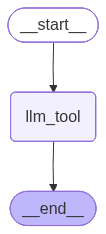

In [61]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
## Invocation

messages = graph.invoke({"messages": "What is 2 plus 2?"})

for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is 2 plus 2?
================================== Ai Message ==================================
Tool Calls:
  add (a8nqd17yx)
 Call ID: a8nqd17yx
  Args:
    a: 2
    b: 2
